# E-Commerce Sales & Customer Analytics - Python EDA

This notebook performs exploratory data analysis for the e-commerce sales project. It covers data loading, cleaning, feature engineering, KPI calculation, visualization, and business insights.

## 1. Import Libraries

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 50)

## 2. Load Dataset

In [2]:
root = Path.cwd()
data_path = root / "data" / "ecommerce_data.xlsx"

if not data_path.exists():
    root = root.parent
    data_path = root / "data" / "ecommerce_data.xlsx"

orders = pd.read_excel(data_path, sheet_name="Orders")
returns = pd.read_excel(data_path, sheet_name="Returns")
people = pd.read_excel(data_path, sheet_name="People")

orders.shape, returns.shape, people.shape

/Users/rajeshreddyatthunuri/Desktop/Data_Projects/E-Commerce-Data-Analysis-main/.venv/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


((51290, 24), (1173, 3), (13, 2))

## 3. Data Cleaning

In [3]:
def clean_columns(df):
    df = df.copy()
    df.columns = (
        df.columns.str.strip()
        .str.lower()
        .str.replace("-", "_", regex=False)
        .str.replace(" ", "_", regex=False)
    )
    return df


orders = clean_columns(orders)
returns = clean_columns(returns)
people = clean_columns(people)

text_columns = ["category", "sub_category", "segment", "market", "region", "ship_mode"]
for column in text_columns:
    orders[column] = orders[column].astype(str).str.strip().str.title()

orders["order_date"] = pd.to_datetime(orders["order_date"])
orders["ship_date"] = pd.to_datetime(orders["ship_date"])

null_summary = orders.isna().sum().sort_values(ascending=False)
duplicate_rows = orders.duplicated().sum()
duplicate_order_products = orders.duplicated(subset=["order_id", "product_id", "product_name"]).sum()
data_types = orders.dtypes

print("Top null counts:")
display(null_summary.head(10))
print(f"Duplicate full rows: {duplicate_rows:,}")
print(f"Duplicate order/product rows: {duplicate_order_products:,}")
display(data_types)

Top null counts:


postal_code      41296
order_id             0
profit               0
shipping_cost        0
discount             0
quantity             0
sales                0
product_name         0
sub_category         0
category             0
dtype: int64

Duplicate full rows: 0
Duplicate order/product rows: 36


row_id                     int64
order_id                     str
order_date        datetime64[us]
ship_date         datetime64[us]
ship_mode                    str
customer_id                  str
customer_name                str
segment                      str
city                         str
state                        str
country                      str
market                       str
postal_code              float64
region                       str
product_id                   str
category                     str
sub_category                 str
product_name                 str
sales                    float64
quantity                   int64
discount                 float64
shipping_cost            float64
profit                   float64
order_priority               str
dtype: object

### Outlier and Category Validation

Outliers are flagged using the IQR method. They are reviewed rather than automatically removed because unusually high sales or shipping values may be valid business transactions.

In [4]:
numeric_columns = ["sales", "quantity", "discount", "shipping_cost", "profit"]
outlier_summary = []

for column in numeric_columns:
    q1 = orders[column].quantile(0.25)
    q3 = orders[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = orders[(orders[column] < lower) | (orders[column] > upper)]
    outlier_summary.append({
        "column": column,
        "lower_bound": lower,
        "upper_bound": upper,
        "potential_outliers": len(outliers)
    })

display(pd.DataFrame(outlier_summary))
orders[["category", "segment", "market", "ship_mode"]].nunique()

,column,lower_bound,upper_bound,potential_outliers
0,sales,-299.683238,581.495063,5655
1,quantity,-2.500000,9.500000,877
2,discount,-0.300000,0.500000,4172
3,shipping_cost,-30.150000,57.210000,5909
4,profit,-55.215000,92.025000,9755


category     3
segment      3
market       7
ship_mode    4
dtype: int64

## 4. Feature Engineering

New fields are created for trend analysis, shipping performance, return tracking, discount bands, and profitability analysis.

In [5]:
orders["order_year"] = orders["order_date"].dt.year
orders["order_month"] = orders["order_date"].dt.month
orders["order_month_name"] = orders["order_date"].dt.strftime("%b")
orders["year_month"] = orders["order_date"].dt.to_period("M").astype(str)
orders["shipping_delay"] = (orders["ship_date"] - orders["order_date"]).dt.days
orders["profit_margin"] = orders["profit"] / orders["sales"]
orders["customer_segment"] = orders["segment"]
orders["sales_bucket"] = pd.cut(
    orders["sales"],
    bins=[-0.01, 100, 500, 1000, float("inf")],
    labels=["Low", "Medium", "High", "Premium"]
)

returned_orders = set(returns["order_id"].dropna())
orders["is_returned"] = orders["order_id"].isin(returned_orders)

orders["discount_band"] = pd.cut(
    orders["discount"],
    bins=[-0.01, 0, 0.10, 0.20, 0.30, 1],
    labels=["No Discount", "0-10%", "10-20%", "20-30%", "30%+"]
)

orders.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,city,state,country,market,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,shipping_cost,profit,order_priority,order_year,order_month,order_month_name,year_month,shipping_delay,profit_margin,customer_segment,sales_bucket,is_returned,discount_band
0,26341,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,United States,Us,10024.0,East,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,933.57,762.1845,Critical,2012,7,Jul,2012-07,0,0.330000,Consumer,Premium,False,No Discount
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,Apac,NaN,Oceania,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,923.63,-288.7650,Critical,2013,2,Feb,2013-02,2,-0.077847,Corporate,Premium,True,0-10%
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,Australia,Apac,NaN,Oceania,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,915.49,919.9710,Medium,2013,10,Oct,2013-10,1,0.177766,Consumer,Premium,False,0-10%
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,Germany,Eu,NaN,Central,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,910.16,-96.5400,Medium,2013,1,Jan,2013-01,2,-0.033376,Home Office,Premium,False,0-10%
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,Senegal,Africa,NaN,Africa,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,903.04,311.5200,Critical,2013,11,Nov,2013-11,1,0.109963,Consumer,Premium,False,No Discount


## 5. KPI Calculations

In [6]:
total_sales = orders["sales"].sum()
total_profit = orders["profit"].sum()
total_orders = orders["order_id"].nunique()
customer_order_counts = orders.groupby("customer_id")["order_id"].nunique()

kpis = pd.Series({
    "Total Sales": total_sales,
    "Total Profit": total_profit,
    "Total Orders": total_orders,
    "Average Order Value": total_sales / total_orders,
    "Profit Margin %": total_profit / total_sales,
    "Top Region": orders.groupby("region")["sales"].sum().idxmax(),
    "Top Category": orders.groupby("category")["sales"].sum().idxmax(),
    "Repeat Customer Rate": (customer_order_counts > 1).mean()
})

kpis

Total Sales             12642501.90988
Total Profit             1467457.29128
Total Orders                     25035
Average Order Value         504.993086
Profit Margin %               0.116073
Top Region                     Central
Top Category                Technology
Repeat Customer Rate          0.993711
dtype: object

## 6. Sales Trend

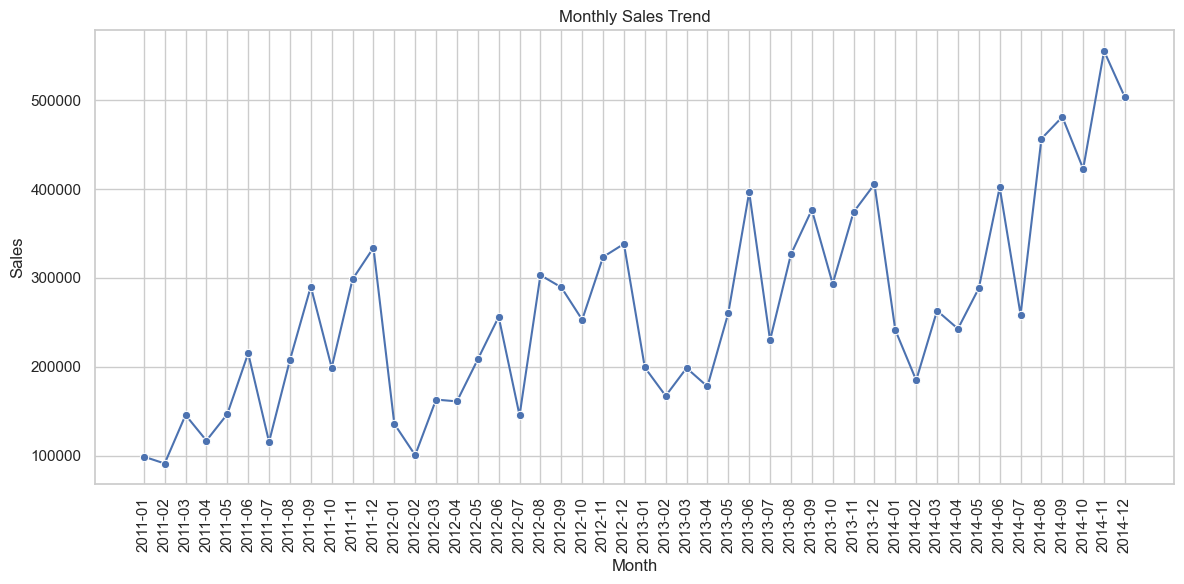

In [7]:
monthly_sales = (
    orders.groupby("year_month", as_index=False)
    .agg(sales=("sales", "sum"), profit=("profit", "sum"))
)

sns.lineplot(data=monthly_sales, x="year_month", y="sales", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Insight:** Monthly sales show how demand changes over time and help identify growth patterns, seasonality, and periods that may need deeper investigation.

### Time-Series Depth

The analysis extends the monthly sales trend with yearly growth, 3-month moving average, seasonality, and peak sales periods.

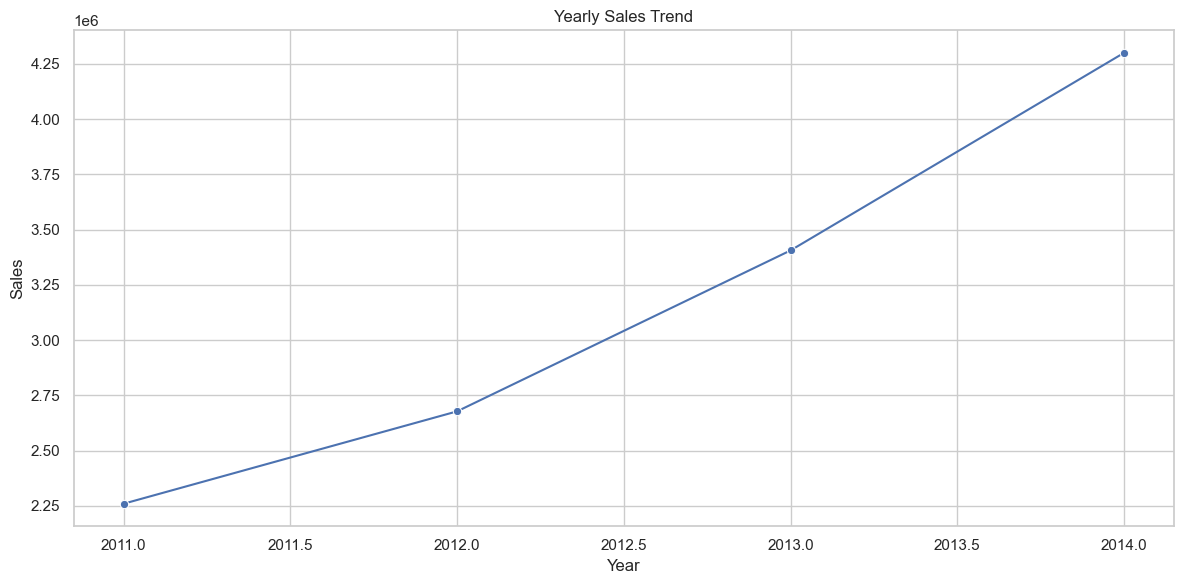

,order_year,sales,profit,orders,profit_margin
0,2011,2.259451e+06,248940.81154,4440,0.110178
1,2012,2.677439e+06,307415.27910,5343,0.114817
2,2013,3.405746e+06,406935.23018,6721,0.119485
3,2014,4.299866e+06,504165.97046,8531,0.117252


In [8]:
yearly_trend = (
    orders.groupby("order_year", as_index=False)
    .agg(sales=("sales", "sum"), profit=("profit", "sum"), orders=("order_id", "nunique"))
    .assign(profit_margin=lambda df: df["profit"] / df["sales"])
)

sns.lineplot(data=yearly_trend, x="order_year", y="sales", marker="o")
plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

yearly_trend

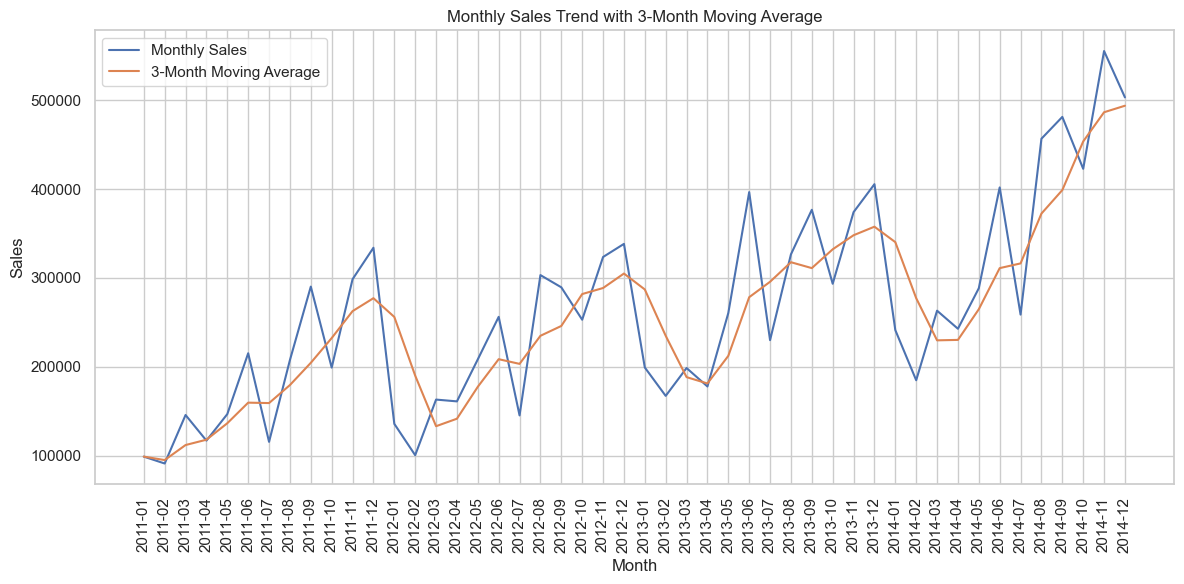

,year_month,sales,profit,sales_moving_avg_3m
36,2014-01,241268.55566,28001.38626,340237.431260
37,2014-02,184837.35556,19751.69996,277186.763080
38,2014-03,263100.77262,37357.26052,229735.561280
39,2014-04,242771.86130,23782.30120,230236.663160
40,2014-05,288401.04614,33953.55774,264757.893353
41,2014-06,401814.06310,43778.60280,310995.656847
42,2014-07,258705.68048,28035.87258,316306.929907
43,2014-08,456619.94236,53542.89496,372379.895313
44,2014-09,481157.24370,67979.45110,398827.622180
45,2014-10,422766.62916,58209.83476,453514.605073


In [9]:
monthly_sales["sales_moving_avg_3m"] = monthly_sales["sales"].rolling(window=3, min_periods=1).mean()

sns.lineplot(data=monthly_sales, x="year_month", y="sales", label="Monthly Sales")
sns.lineplot(data=monthly_sales, x="year_month", y="sales_moving_avg_3m", label="3-Month Moving Average")
plt.title("Monthly Sales Trend with 3-Month Moving Average")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

monthly_sales.tail(12)

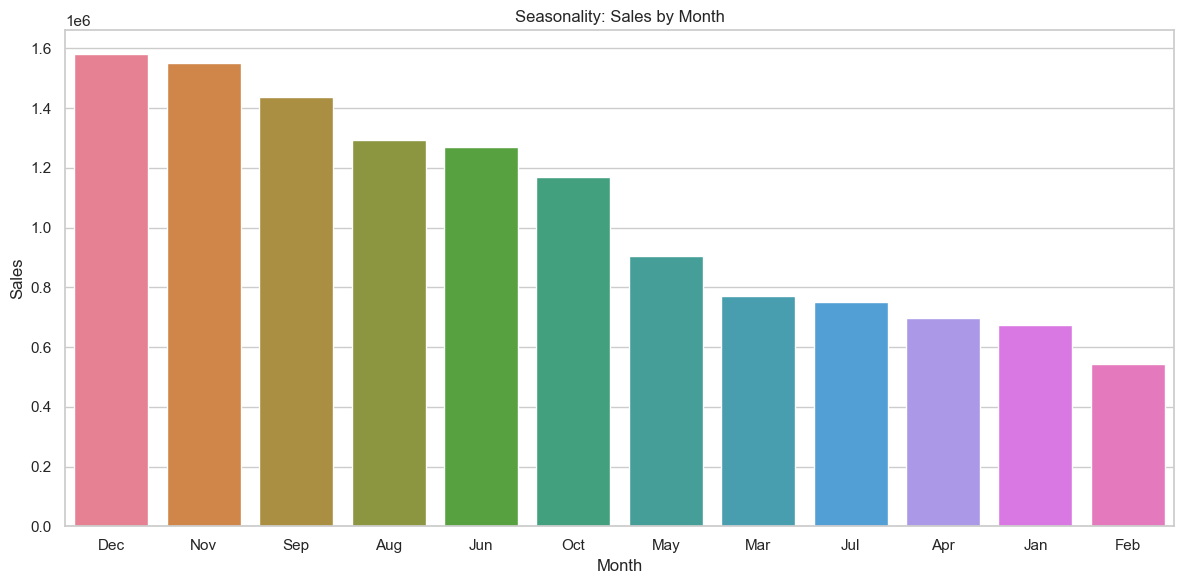

,order_month,order_month_name,sales,profit,orders,avg_sales_per_order
11,12,Dec,1.580781e+06,170718.12710,3166,499.299044
10,11,Nov,1.551277e+06,175449.48412,3145,493.251937
8,9,Sep,1.437380e+06,170438.18316,3021,475.796131
7,8,Aug,1.293833e+06,151854.10972,2500,517.533266
5,6,Jun,1.269717e+06,147079.41684,2662,476.978495
9,10,Oct,1.168184e+06,157269.35838,2290,510.124186
4,5,May,9.040123e+05,104509.78428,1897,476.548412
2,3,Mar,7.705009e+05,94087.52096,1555,495.498998
6,7,Jul,7.493818e+05,78070.09172,1561,480.065238
3,4,Apr,6.985612e+05,73513.63124,1506,463.852066


In [10]:
seasonality = (
    orders.groupby(["order_month", "order_month_name"], as_index=False)
    .agg(sales=("sales", "sum"), profit=("profit", "sum"), orders=("order_id", "nunique"))
    .assign(avg_sales_per_order=lambda df: df["sales"] / df["orders"])
    .sort_values("sales", ascending=False)
)

sns.barplot(data=seasonality, x="order_month_name", y="sales", hue="order_month_name", legend=False)
plt.title("Seasonality: Sales by Month")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

seasonality

In [11]:
peak_sales_periods = monthly_sales.sort_values("sales", ascending=False).head(10)
peak_sales_periods

,year_month,sales,profit,sales_moving_avg_3m
46,2014-11,555279.02700,62856.58790,486400.966620
47,2014-12,503143.69348,46916.52068,493729.783213
44,2014-09,481157.24370,67979.45110,398827.622180
43,2014-08,456619.94236,53542.89496,372379.895313
45,2014-10,422766.62916,58209.83476,453514.605073
35,2013-12,405454.37802,50202.87112,357616.793667
41,2014-06,401814.06310,43778.60280,310995.656847
29,2013-06,396519.61190,45478.41340,278279.831147
32,2013-09,376619.24568,38905.66778,311012.329013
34,2013-11,373989.36010,48062.99670,348005.082887


**Insight:** Time-series analysis helps identify growth trends, seasonal demand patterns, and peak sales periods that can guide inventory, marketing, and staffing decisions.

## 7. Category and Sub-Category Performance

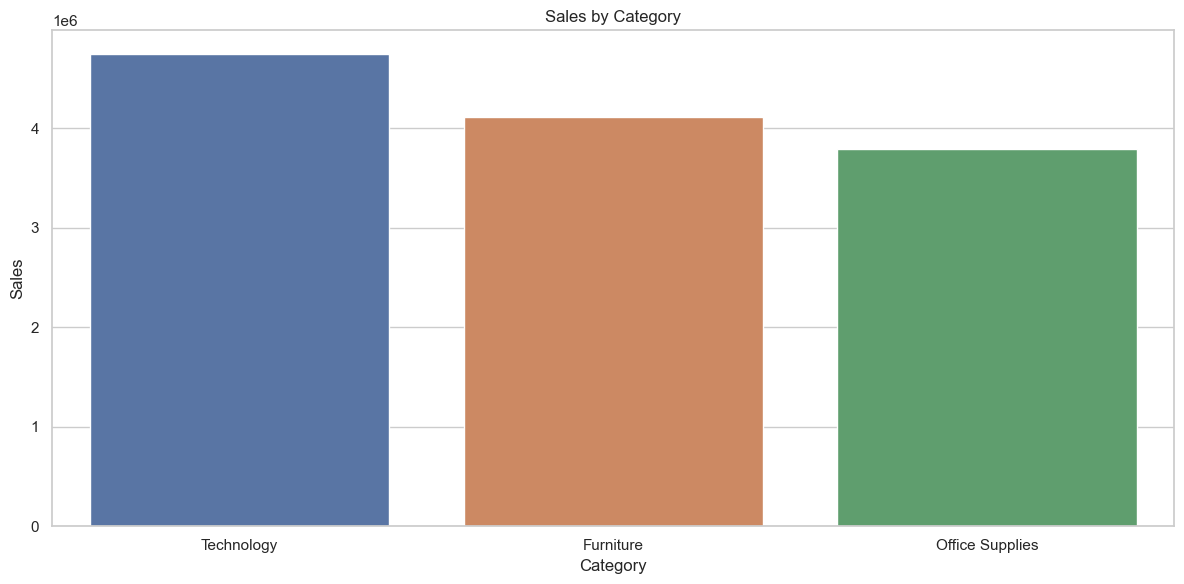

,category,sales,profit,quantity
2,Technology,4.744557e+06,663778.73318,35176
0,Furniture,4.110874e+06,285204.72380,34954
1,Office Supplies,3.787070e+06,518473.83430,108182


In [12]:
category_perf = (
    orders.groupby("category", as_index=False)
    .agg(sales=("sales", "sum"), profit=("profit", "sum"), quantity=("quantity", "sum"))
    .sort_values("sales", ascending=False)
)

sns.barplot(data=category_perf, x="category", y="sales", hue="category", legend=False)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

category_perf

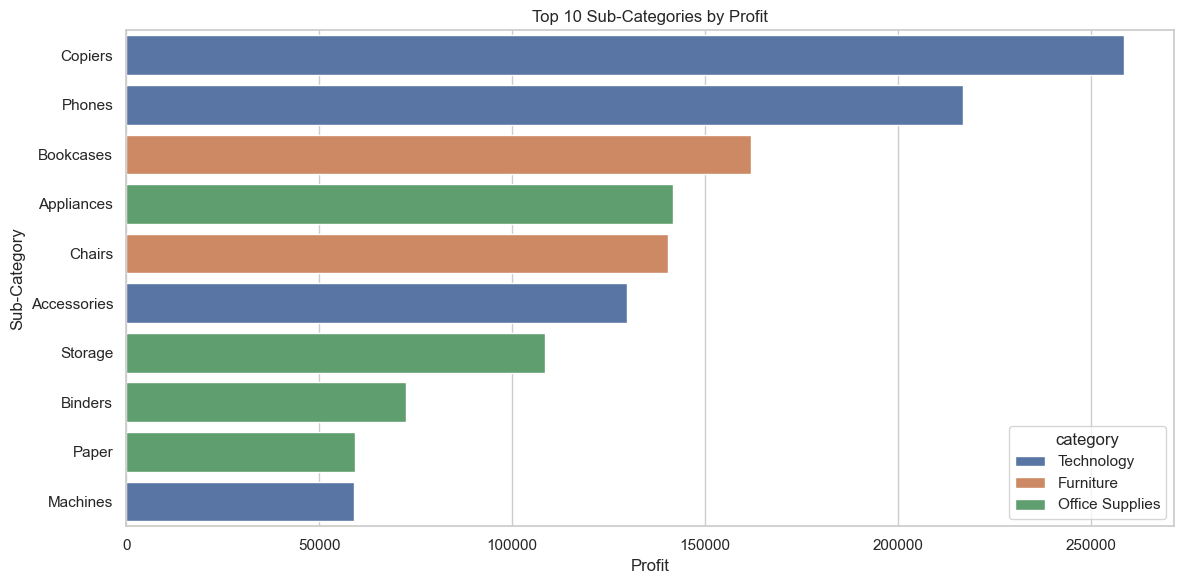

,category,sub_category,sales,profit
14,Technology,Copiers,1.509436e+06,258567.54818
16,Technology,Phones,1.706824e+06,216717.00580
0,Furniture,Bookcases,1.466572e+06,161924.41950
4,Office Supplies,Appliances,1.011064e+06,141680.58940
1,Furniture,Chairs,1.501682e+06,140396.26750
13,Technology,Accessories,7.492370e+05,129626.30620
11,Office Supplies,Storage,1.127086e+06,108461.48980
6,Office Supplies,Binders,4.619115e+05,72449.84600
10,Office Supplies,Paper,2.442917e+05,59207.68270
15,Technology,Machines,7.790601e+05,58867.87300


In [13]:
subcategory_profit = (
    orders.groupby(["category", "sub_category"], as_index=False)
    .agg(sales=("sales", "sum"), profit=("profit", "sum"))
    .sort_values("profit", ascending=False)
)

sns.barplot(data=subcategory_profit.head(10), y="sub_category", x="profit", hue="category")
plt.title("Top 10 Sub-Categories by Profit")
plt.xlabel("Profit")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

subcategory_profit.head(10)

**Insight:** Category-level sales should be compared with profit, because high revenue does not always mean strong profitability.

## 8. Profitability Analysis

This section focuses on profit by category, loss-making products, low-margin products, and the relationship between discounting and profit.

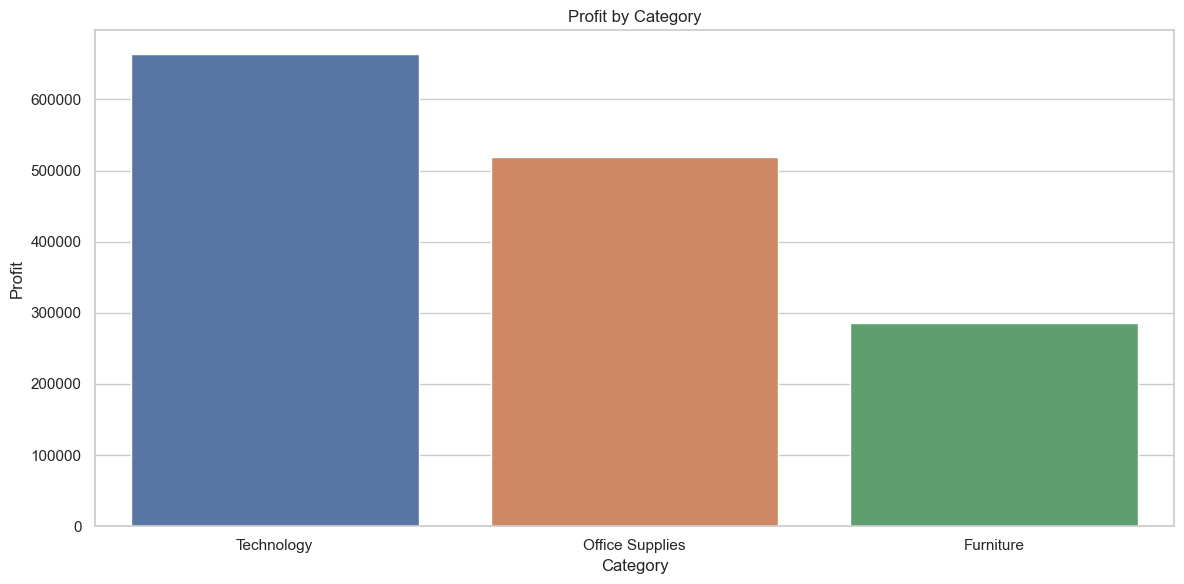

,category,sales,profit,avg_discount,profit_margin
2,Technology,4.744557e+06,663778.73318,0.135342,0.139903
1,Office Supplies,3.787070e+06,518473.83430,0.137409,0.136906
0,Furniture,4.110874e+06,285204.72380,0.168087,0.069378


In [14]:
profit_by_category = (
    orders.groupby("category", as_index=False)
    .agg(sales=("sales", "sum"), profit=("profit", "sum"), avg_discount=("discount", "mean"))
    .assign(profit_margin=lambda df: df["profit"] / df["sales"])
    .sort_values("profit", ascending=False)
)

sns.barplot(data=profit_by_category, x="category", y="profit", hue="category", legend=False)
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

profit_by_category

In [15]:
product_profitability = (
    orders.groupby(["product_id", "product_name", "category", "sub_category"], as_index=False)
    .agg(sales=("sales", "sum"), profit=("profit", "sum"), avg_discount=("discount", "mean"))
    .assign(profit_margin=lambda df: df["profit"] / df["sales"])
)

loss_making_products = product_profitability.query("profit < 0").sort_values("profit").head(10)
low_margin_products = product_profitability.query("sales > 0").sort_values("profit_margin").head(10)

display(loss_making_products)
display(low_margin_products)

,product_id,product_name,category,sub_category,sales,profit,avg_discount,profit_margin
9574,TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,11099.9630,-8879.9704,0.533333,-0.800000
2614,OFF-AP-10001623,"Hoover Stove, White",Office Supplies,Appliances,11728.8270,-4958.1630,0.200000,-0.422733
9605,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,16829.9010,-4589.9730,0.400000,-0.272727
10424,TEC-PH-10002991,"Apple Smart Phone, Full Size",Technology,Phones,7259.1561,-4574.6439,0.355000,-0.630189
9984,TEC-MOT-10003050,"Motorola Smart Phone, Cordless",Technology,Phones,10348.7580,-3998.6820,0.185714,-0.386392
9876,TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,Technology,Machines,7999.9800,-3839.9904,0.500000,-0.480000
699,FUR-CH-10001582,"Office Star Executive Leather Armchair, Black",Furniture,Chairs,6497.2770,-3066.7830,0.280000,-0.472011
1993,FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,Tables,9917.6400,-2876.1156,0.280000,-0.290000
2157,FUR-TA-10002885,"Lesro Computer Table, Fully Assembled",Furniture,Tables,1199.3520,-2798.4880,0.700000,-2.333333
2118,FUR-TA-10002172,"Hon Conference Table, Rectangular",Furniture,Tables,3667.0095,-2619.3105,0.590000,-0.714291


,product_id,product_name,category,sub_category,sales,profit,avg_discount,profit_margin
2105,FUR-TA-10001935,"Hon Coffee Table, Fully Assembled",Furniture,Tables,190.422,-733.158,0.800,-3.850175
2244,FUR-TA-10003963,"Bevis Conference Table, Fully Assembled",Furniture,Tables,555.138,-1924.542,0.850,-3.466781
2277,FUR-TA-10004544,"Chromcraft Coffee Table, Fully Assembled",Furniture,Tables,456.552,-1391.208,0.725,-3.047206
2663,OFF-AP-10002203,Eureka Disposable Bags for Sanitaire Vibra Gro...,Office Supplies,Appliances,1.624,-4.466,0.800,-2.750000
2228,FUR-TA-10003748,"Bevis Round Table, Adjustable Height",Furniture,Tables,312.228,-780.642,0.800,-2.500231
2157,FUR-TA-10002885,"Lesro Computer Table, Fully Assembled",Furniture,Tables,1199.352,-2798.488,0.700,-2.333333
8263,OFF-XER-10000566,"Xerox Note Cards, 8.5 x 11",Office Supplies,Paper,73.224,-168.456,0.700,-2.300557
9867,TEC-MA-10003998,"Epson Card Printer, Wireless",Technology,Machines,237.930,-547.330,0.700,-2.300382
9497,TEC-HP -10004971,"HP Wireless Fax, Color",Technology,Copiers,216.990,-499.110,0.700,-2.300152
2197,FUR-TA-10003371,"Chromcraft Training Table, Adjustable Height",Furniture,Tables,38.144,-87.736,0.800,-2.300126


**Insight:** Loss-making and low-margin products should be reviewed for pricing, discounting, sourcing cost, or fulfillment issues before increasing promotion spend.

## 9. Market and Regional Performance

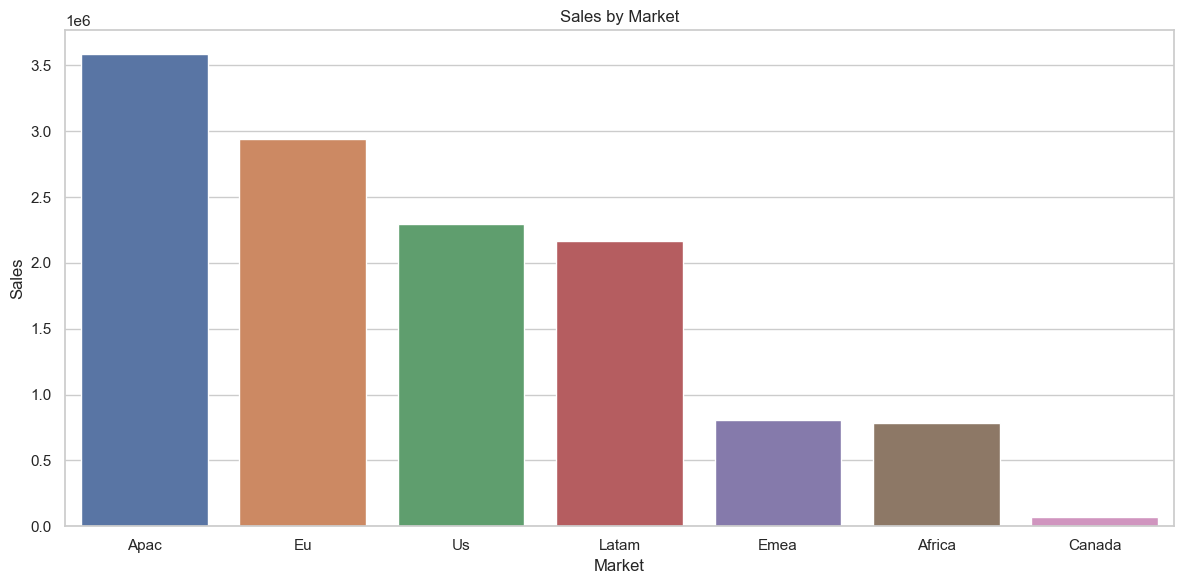

,market,sales,profit,orders,profit_margin
1,Apac,3.585744e+06,436000.04900,5437,0.121593
4,Eu,2.938089e+06,372829.74150,4593,0.126895
6,Us,2.297201e+06,286397.02170,5009,0.124672
5,Latam,2.164605e+06,221643.48708,5138,0.102394
3,Emea,8.061613e+05,43897.97100,2462,0.054453
0,Africa,7.837732e+05,88871.63100,2232,0.113389
2,Canada,6.692817e+04,17817.39000,201,0.266217


In [16]:
market_perf = (
    orders.groupby("market", as_index=False)
    .agg(sales=("sales", "sum"), profit=("profit", "sum"), orders=("order_id", "nunique"))
    .assign(profit_margin=lambda df: df["profit"] / df["sales"])
    .sort_values("sales", ascending=False)
)

sns.barplot(data=market_perf, x="market", y="sales", hue="market", legend=False)
plt.title("Sales by Market")
plt.xlabel("Market")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

market_perf

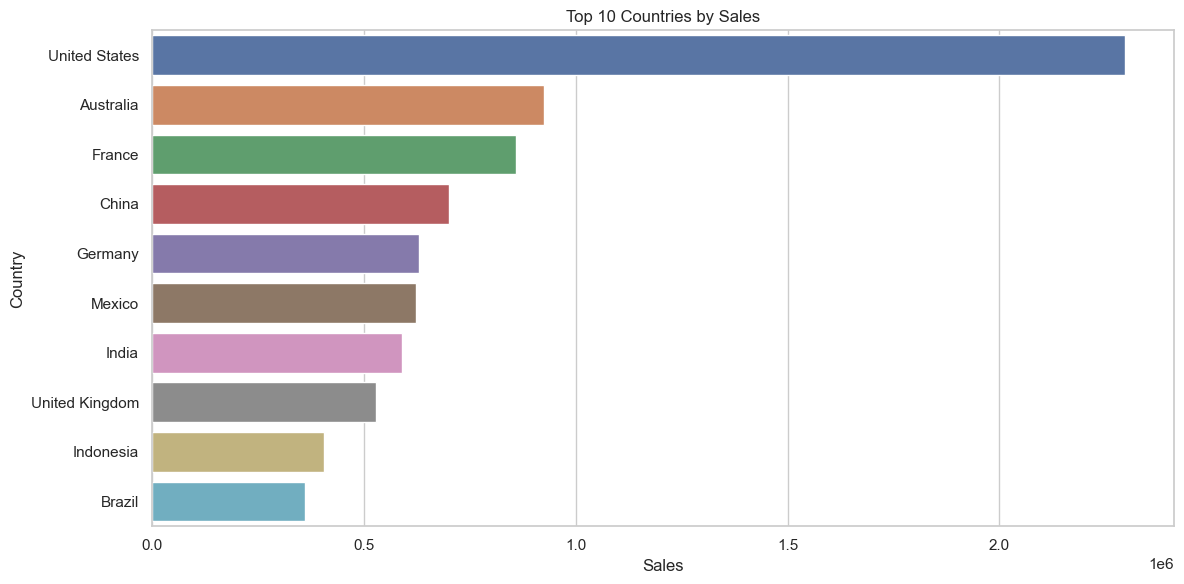

,country,sales,profit
139,United States,2.297201e+06,286397.02170
6,Australia,9.252359e+05,103907.43300
44,France,8.589311e+05,109029.00300
26,China,7.005620e+05,150683.08500
47,Germany,6.288400e+05,107322.82050
81,Mexico,6.225906e+05,102818.09752
57,India,5.896501e+05,129071.83500
138,United Kingdom,5.285763e+05,111900.15000
58,Indonesia,4.048875e+05,15608.67790
17,Brazil,3.611064e+05,30090.49896


In [17]:
top_countries = (
    orders.groupby("country", as_index=False)
    .agg(sales=("sales", "sum"), profit=("profit", "sum"))
    .sort_values("sales", ascending=False)
    .head(10)
)

sns.barplot(data=top_countries, y="country", x="sales", hue="country", legend=False)
plt.title("Top 10 Countries by Sales")
plt.xlabel("Sales")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

top_countries

**Insight:** Market and country performance highlights where the business should prioritize expansion, retention, and operational support.

### Regional Analysis Depth

This section expands geographic analysis beyond basic map visuals by comparing profit, state sales, city performance, and regional growth trends.

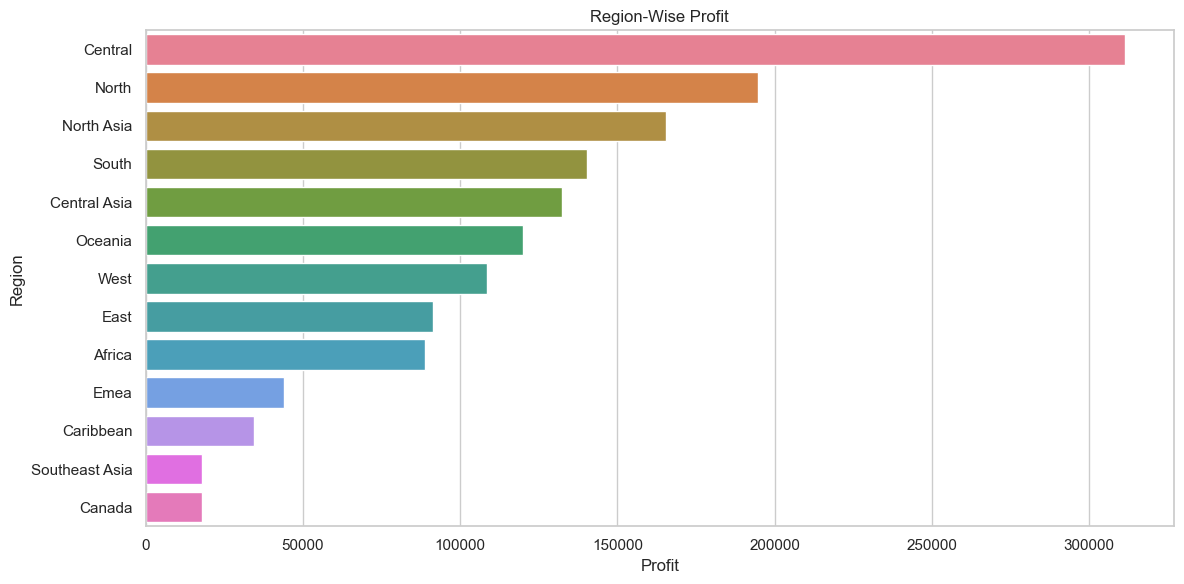

,region,sales,profit,orders,profit_margin
3,Central,2.822303e+06,311403.98164,5249,0.110337
7,North,1.248166e+06,194597.95252,2356,0.155907
8,North Asia,8.483098e+05,165578.42100,1150,0.195186
10,South,1.600907e+06,140355.76618,3270,0.087673
4,Central Asia,7.528266e+05,132480.18700,1026,0.175977
9,Oceania,1.100185e+06,120089.11200,1744,0.109154
12,West,7.254578e+05,108418.44890,1611,0.149448
5,East,6.787812e+05,91522.78000,1401,0.134834
0,Africa,7.837732e+05,88871.63100,2232,0.113389
6,Emea,8.061613e+05,43897.97100,2462,0.054453


In [18]:
region_profit = (
    orders.groupby("region", as_index=False)
    .agg(sales=("sales", "sum"), profit=("profit", "sum"), orders=("order_id", "nunique"))
    .assign(profit_margin=lambda df: df["profit"] / df["sales"])
    .sort_values("profit", ascending=False)
)

sns.barplot(data=region_profit, y="region", x="profit", hue="region", legend=False)
plt.title("Region-Wise Profit")
plt.xlabel("Profit")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

region_profit

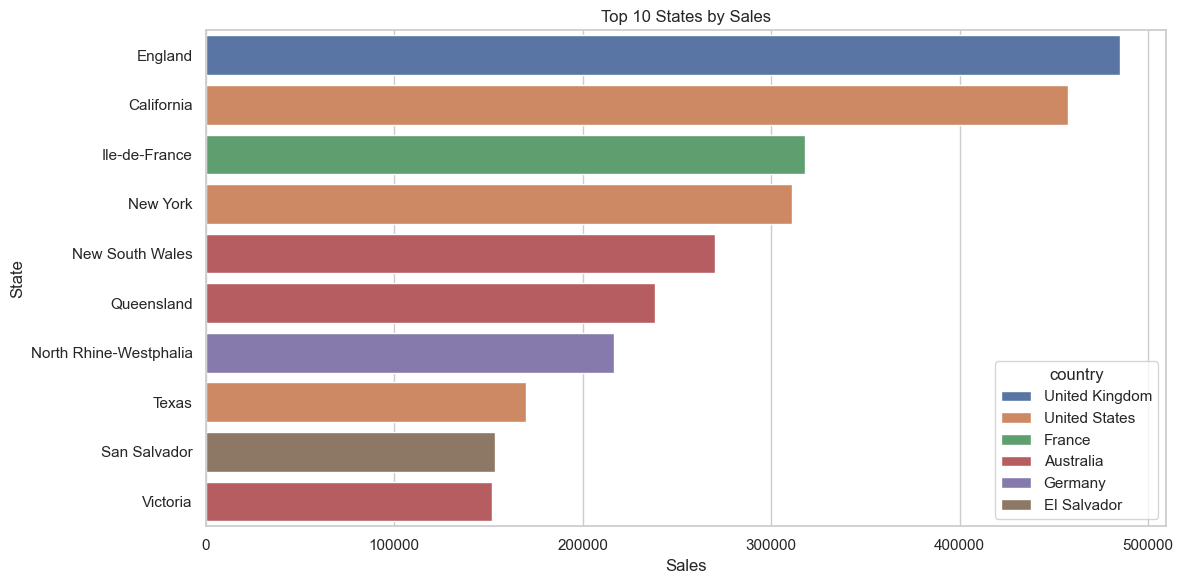

,country,state,sales,profit,orders,profit_margin
1019,United Kingdom,England,485170.9710,99907.7310,699,0.205923
1025,United States,California,457687.6315,76381.3871,1021,0.166885
336,France,Ile-de-France,317822.5440,44055.9240,468,0.138618
1052,United States,New York,310876.2710,74038.5486,562,0.238161
56,Australia,New South Wales,270487.1040,43695.9840,388,0.161546
58,Australia,Queensland,238312.7340,21608.7540,374,0.090674
361,Germany,North Rhine-Westphalia,216451.8510,42347.8710,336,0.195646
1063,United States,Texas,170188.0458,-25729.3563,487,-0.151182
316,El Salvador,San Salvador,153639.3970,35883.3770,307,0.233556
61,Australia,Victoria,151785.0300,14929.0800,252,0.098357


In [19]:
top_states = (
    orders.groupby(["country", "state"], as_index=False)
    .agg(sales=("sales", "sum"), profit=("profit", "sum"), orders=("order_id", "nunique"))
    .assign(profit_margin=lambda df: df["profit"] / df["sales"])
    .sort_values("sales", ascending=False)
    .head(10)
)

sns.barplot(data=top_states, y="state", x="sales", hue="country")
plt.title("Top 10 States by Sales")
plt.xlabel("Sales")
plt.ylabel("State")
plt.tight_layout()
plt.show()

top_states

In [20]:
top_cities = (
    orders.groupby(["country", "state", "city"], as_index=False)
    .agg(sales=("sales", "sum"), profit=("profit", "sum"), orders=("order_id", "nunique"))
    .assign(profit_margin=lambda df: df["profit"] / df["sales"])
    .sort_values("sales", ascending=False)
    .head(10)
)

top_cities

,country,state,city,sales,profit,orders,profit_margin
3523,United States,New York,New York City,256368.16100,62036.98370,450,0.241984
3197,United States,California,Los Angeles,175851.34100,30440.75790,384,0.173105
2474,Philippines,National Capital,Manila,120886.94850,-11158.56150,206,-0.092306
3720,United States,Washington,Seattle,119540.74200,29156.09670,212,0.243901
3224,United States,California,San Francisco,112669.09200,17507.38540,265,0.155388
3597,United States,Pennsylvania,Philadelphia,109077.01300,-13837.76740,265,-0.126862
89,Australia,New South Wales,Sydney,101945.51700,16002.80700,131,0.156974
1743,Indonesia,Jakarta,Jakarta,94321.32420,3826.98420,164,0.040574
2142,Mexico,Distrito Federal,Mexico City,85728.55176,13342.29176,162,0.155634
2366,Nicaragua,Managua,Managua,83707.49804,17853.71804,176,0.213287


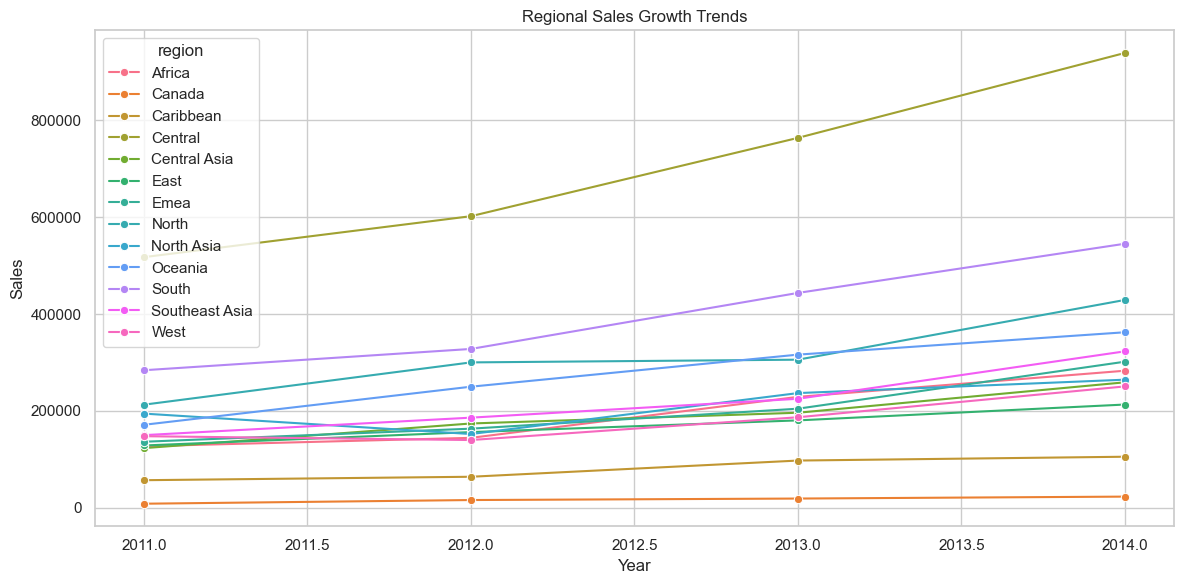

,region,order_year,sales,profit,yoy_sales_growth
0,Africa,2011,127187.27400,10944.11400,NaN
1,Africa,2012,144480.70500,11908.93500,0.135968
2,Africa,2013,229068.79200,26687.11200,0.585463
3,Africa,2014,283036.44000,39331.47000,0.235596
4,Canada,2011,8509.11000,1807.08000,NaN
5,Canada,2012,16096.80000,4887.84000,0.891714
6,Canada,2013,19161.15000,5129.46000,0.190370
7,Canada,2014,23161.11000,5993.01000,0.208754
8,Caribbean,2011,57043.42896,4358.90896,NaN
9,Caribbean,2012,64147.57692,8706.25692,0.124539


In [21]:
regional_growth = (
    orders.groupby(["region", "order_year"], as_index=False)
    .agg(sales=("sales", "sum"), profit=("profit", "sum"))
    .sort_values(["region", "order_year"])
)
regional_growth["yoy_sales_growth"] = regional_growth.groupby("region")["sales"].pct_change()

sns.lineplot(data=regional_growth, x="order_year", y="sales", hue="region", marker="o")
plt.title("Regional Sales Growth Trends")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

regional_growth

**Insight:** Regional depth helps separate high-revenue markets from high-profit regions and shows where growth is accelerating or weakening over time.

## 10. Customer Segment Analysis

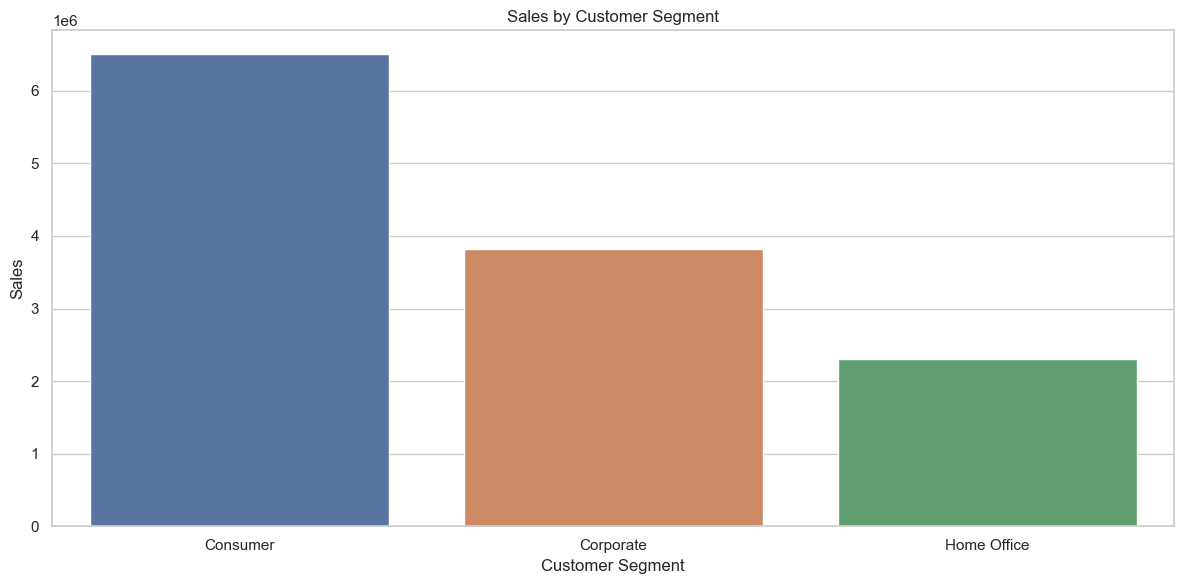

,customer_segment,customers,orders,sales,profit,profit_margin
0,Consumer,818,13104,6.507949e+06,749239.78206,0.115127
1,Corporate,476,7673,3.824698e+06,441208.32866,0.115358
2,Home Office,296,4687,2.309855e+06,277009.18056,0.119925


In [22]:
segment_perf = (
    orders.groupby("customer_segment", as_index=False)
    .agg(
        customers=("customer_id", "nunique"),
        orders=("order_id", "nunique"),
        sales=("sales", "sum"),
        profit=("profit", "sum")
    )
    .assign(profit_margin=lambda df: df["profit"] / df["sales"])
    .sort_values("sales", ascending=False)
)

sns.barplot(data=segment_perf, x="customer_segment", y="sales", hue="customer_segment", legend=False)
plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

segment_perf

**Insight:** Segment analysis shows which customer groups are most valuable and where targeted campaigns may improve revenue or margin.

## 11. Customer Depth Analysis

This section identifies top customers, repeat customers, basic customer lifetime value, and sales by customer type.

In [23]:
customer_summary = (
    orders.groupby(["customer_id", "customer_name", "customer_segment"], as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum")
    )
    .assign(
        average_order_value=lambda df: df["sales"] / df["orders"],
        basic_clv=lambda df: df["sales"],
        profit_margin=lambda df: df["profit"] / df["sales"],
        customer_type=lambda df: df["orders"].map(lambda orders: "Repeat Customer" if orders > 1 else "One-Time Customer")
    )
)

top_customers = customer_summary.sort_values("sales", ascending=False).head(10)
top_customers

,customer_id,customer_name,customer_segment,orders,sales,profit,quantity,average_order_value,basic_clv,profit_margin,customer_type
1463,TA-21385,Tom Ashbrook,Home Office,25,35668.12080,6274.98910,239,1426.724832,35668.12080,0.175927,Repeat Customer
623,GT-14710,Greg Tran,Consumer,30,34471.89028,5164.84718,284,1149.063009,34471.89028,0.149828,Repeat Customer
1489,TC-20980,Tamara Chand,Corporate,28,34218.26900,8787.47490,209,1222.081036,34218.26900,0.256807,Repeat Customer
1405,SM-20320,Sean Miller,Home Office,21,31125.29496,-1083.67434,139,1482.156903,31125.29496,-0.034817,Repeat Customer
237,BW-11110,Bart Watters,Corporate,35,30613.61650,3337.46590,316,874.674757,30613.61650,0.109019,Repeat Customer
656,HL-15040,Hunter Lopez,Consumer,20,29664.23058,7657.50178,199,1483.211529,29664.23058,0.258139,Repeat Customer
1369,SE-20110,Sanjit Engle,Consumer,36,29532.62502,5863.62392,286,820.350695,29532.62502,0.198547,Repeat Customer
1220,PS-19045,Penelope Sewall,Home Office,26,29252.31940,4426.19510,259,1125.089208,29252.31940,0.151311,Repeat Customer
1243,RB-19360,Raymond Buch,Consumer,25,29197.63460,8523.95150,248,1167.905384,29197.63460,0.291940,Repeat Customer
1587,ZC-21910,Zuschuss Carroll,Consumer,37,28472.81926,452.50326,333,769.535656,28472.81926,0.015892,Repeat Customer


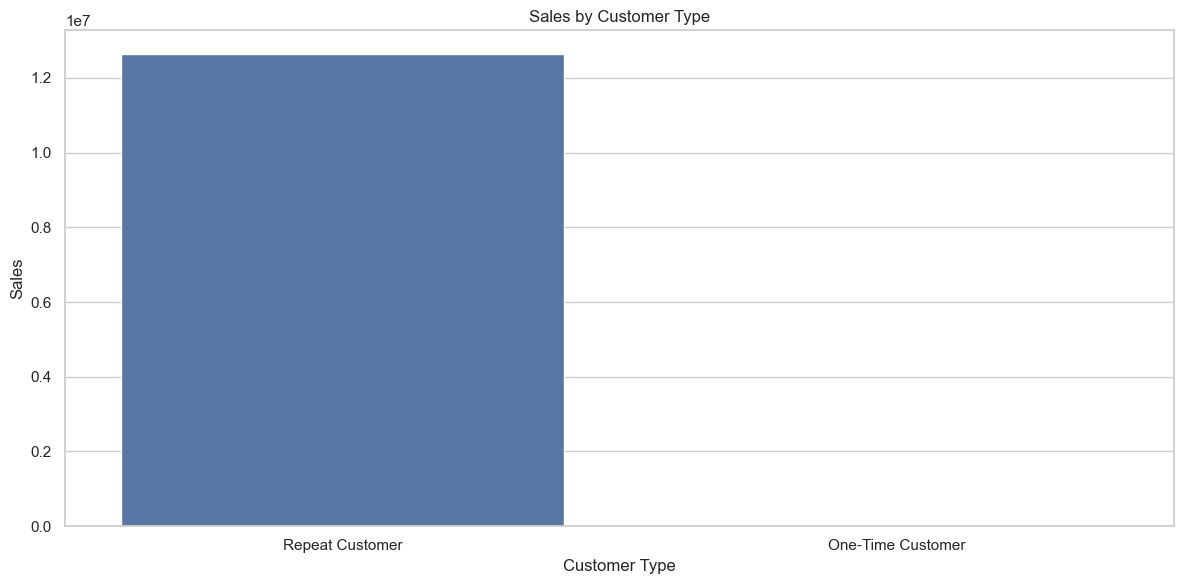

,customer_type,customers,sales,profit,avg_clv,profit_margin
1,Repeat Customer,1580,1.263934e+07,1.468247e+06,7999.579956,0.116165
0,One-Time Customer,10,3.165579e+03,-7.897110e+02,316.557900,-0.249468


In [24]:
customer_type_perf = (
    customer_summary.groupby("customer_type", as_index=False)
    .agg(customers=("customer_id", "nunique"), sales=("sales", "sum"), profit=("profit", "sum"), avg_clv=("basic_clv", "mean"))
    .assign(profit_margin=lambda df: df["profit"] / df["sales"])
    .sort_values("sales", ascending=False)
)

sns.barplot(data=customer_type_perf, x="customer_type", y="sales", hue="customer_type", legend=False)
plt.title("Sales by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

customer_type_perf

**Insight:** Top customers and repeat customers help identify retention opportunities and accounts that drive long-term revenue value.

## 12. Sales Bucket Analysis

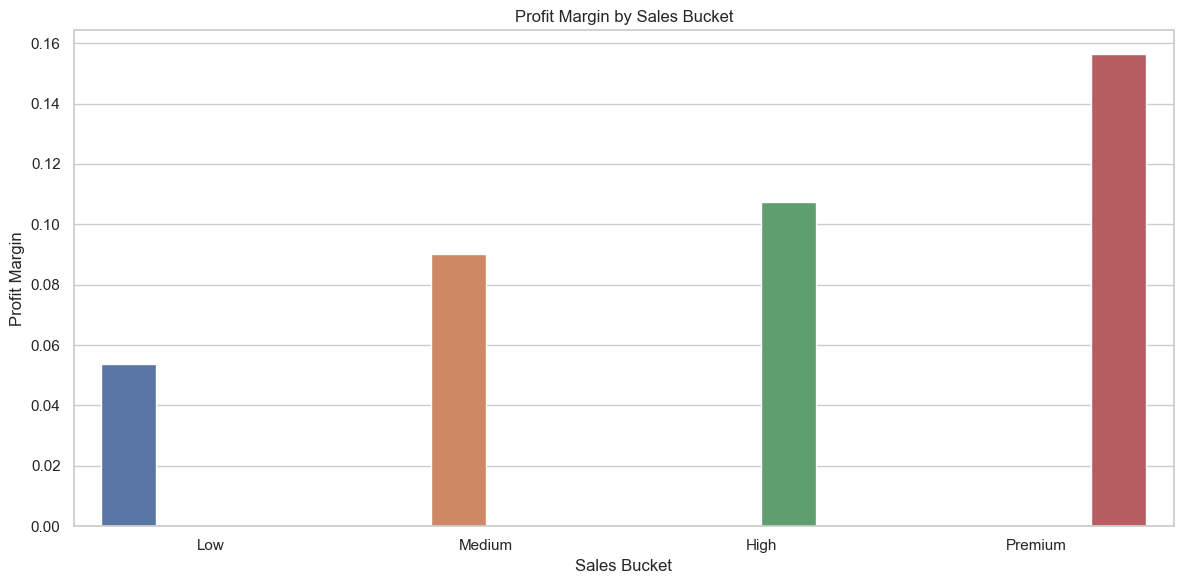

,sales_bucket,line_items,sales,profit,profit_margin
0,Low,27843,1.102546e+06,59137.15790,0.053637
1,Medium,16695,3.859717e+06,348469.25754,0.090284
2,High,4126,2.876502e+06,308522.53604,0.107256
3,Premium,2626,4.803737e+06,751328.33980,0.156405


In [25]:
sales_bucket_perf = (
    orders.groupby("sales_bucket", observed=False, as_index=False)
    .agg(line_items=("order_id", "count"), sales=("sales", "sum"), profit=("profit", "sum"))
    .assign(profit_margin=lambda df: df["profit"] / df["sales"])
)

sns.barplot(data=sales_bucket_perf, x="sales_bucket", y="profit_margin", hue="sales_bucket", legend=False)
plt.title("Profit Margin by Sales Bucket")
plt.xlabel("Sales Bucket")
plt.ylabel("Profit Margin")
plt.tight_layout()
plt.show()

sales_bucket_perf

**Insight:** Sales buckets help compare smaller transactions with high-value orders and show whether larger transactions are also more profitable.

## 13. Discount Impact on Profitability

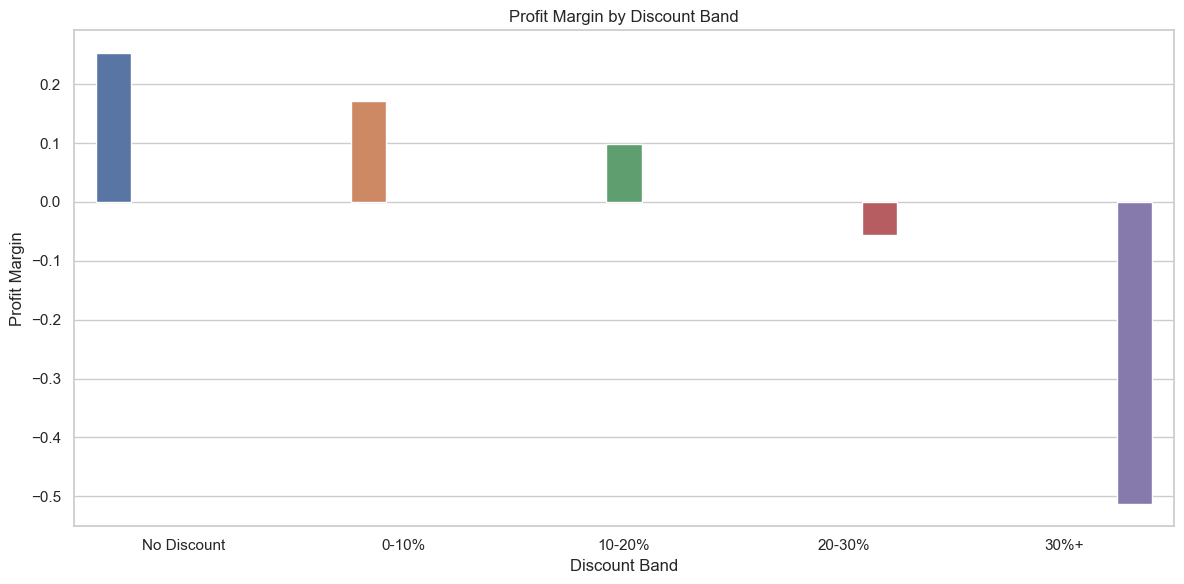

,discount_band,line_items,sales,profit,profit_margin
0,No Discount,29009,6.992411e+06,1.770695e+06,0.253231
1,0-10%,4679,1.962619e+06,3.381893e+05,0.172315
2,10-20%,6274,1.757261e+06,1.732548e+05,0.098594
3,20-30%,967,3.825547e+05,-2.115561e+04,-0.055301
4,30%+,10361,1.547656e+06,-7.935265e+05,-0.512728


In [26]:
discount_perf = (
    orders.groupby("discount_band", observed=False, as_index=False)
    .agg(line_items=("order_id", "count"), sales=("sales", "sum"), profit=("profit", "sum"))
    .assign(profit_margin=lambda df: df["profit"] / df["sales"])
)

sns.barplot(data=discount_perf, x="discount_band", y="profit_margin", hue="discount_band", legend=False)
plt.title("Profit Margin by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Profit Margin")
plt.tight_layout()
plt.show()

discount_perf

**Insight:** Discount bands reveal whether higher discounts are helping sales or damaging profitability. This supports a more controlled promotional strategy.

## 14. Shipping and Return Analysis

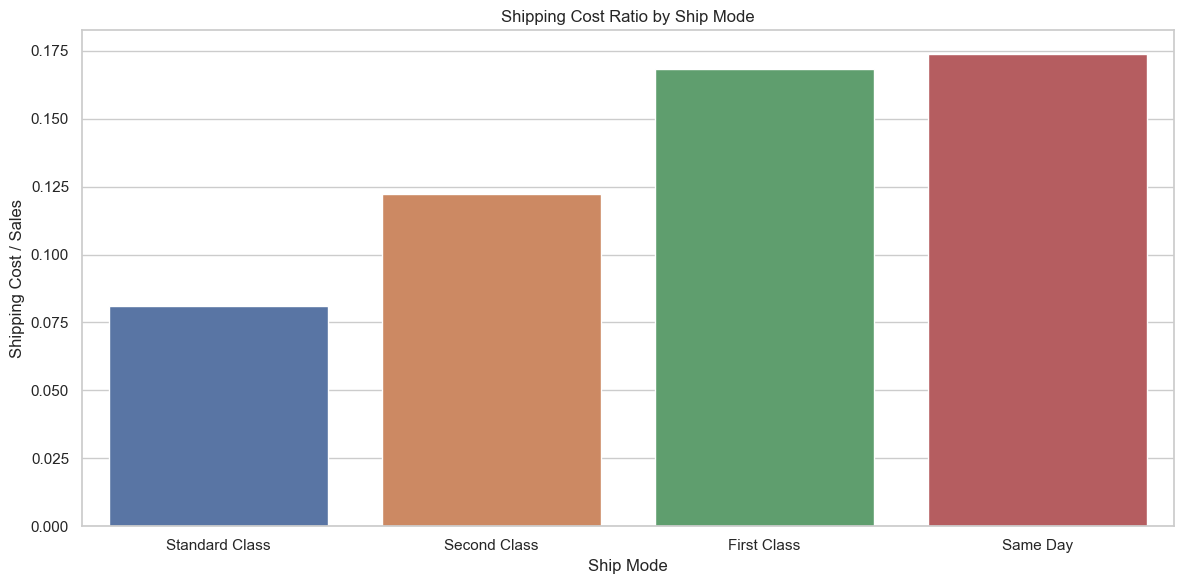

,ship_mode,orders,sales,shipping_cost,avg_shipping_delay,shipping_cost_ratio
3,Standard Class,15154,7.578652e+06,614627.65550,4.998018,0.081100
2,Second Class,5119,2.565672e+06,314111.79036,3.230187,0.122429
0,First Class,3821,1.830976e+06,308102.54154,2.181746,0.168272
1,Same Day,1347,6.672020e+05,115973.71600,0.037394,0.173821


In [27]:
ship_perf = (
    orders.groupby("ship_mode", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        sales=("sales", "sum"),
        shipping_cost=("shipping_cost", "sum"),
        avg_shipping_delay=("shipping_delay", "mean")
    )
    .assign(shipping_cost_ratio=lambda df: df["shipping_cost"] / df["sales"])
    .sort_values("sales", ascending=False)
)

sns.barplot(data=ship_perf, x="ship_mode", y="shipping_cost_ratio", hue="ship_mode", legend=False)
plt.title("Shipping Cost Ratio by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Shipping Cost / Sales")
plt.tight_layout()
plt.show()

ship_perf

In [28]:
return_by_market = (
    orders.groupby("market", as_index=False)
    .agg(total_orders=("order_id", "nunique"), returned_orders=("is_returned", "sum"))
    .assign(return_rate=lambda df: df["returned_orders"] / df["total_orders"])
    .sort_values("return_rate", ascending=False)
)

return_by_market

,market,total_orders,returned_orders,return_rate
5,Latam,5138,825,0.160568
6,Us,5009,802,0.160112
1,Apac,5437,786,0.144565
4,Eu,4593,637,0.138689
0,Africa,2232,0,0.000000
2,Canada,201,0,0.000000
3,Emea,2462,0,0.000000


**Insight:** Shipping mode and return-rate analysis can help identify operational areas that affect customer satisfaction and margin.

## 15. Final Business Recommendations

- Prioritize high-sales markets while monitoring profit margin, not just revenue.
- Review sub-categories with high sales but weak or negative profit.
- Set discount guardrails for products and regions where discounts reduce margin.
- Track returns by market and category to identify quality or fulfillment issues.
- Use customer segment performance to design targeted marketing and retention campaigns.
- Combine growth goals with profit-margin guardrails so expansion improves both revenue and business value.